In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.feature_evaluation import FeatureEvaluator

In [3]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader1 = VesselDataLoader(raw_data_file1)
loader2 = VesselDataLoader(raw_data_file2)

# Load and clean the data
df1 = loader1.load_and_clean()
df2 = loader2.load_and_clean()

base_features = ['AE_POWER(kW)', 'SHIP SPEED(knots)', 'NUM_GENERATORS']
engineered_features = ['GEN_TRANSITION', 'LOAD_SYMMETRY_ERROR', 'ROT_DEG_PER_MIN', 'ENERGY_INTENSITY', 'POWER_TV_ENERGY', 'PF_EFFECTIVE', 'PF_DERIVATIVE']
all_features = base_features + engineered_features

Successfully loaded, cleaned, and processed 2880 telemetry rows.
Successfully loaded, cleaned, and processed 3168 telemetry rows.


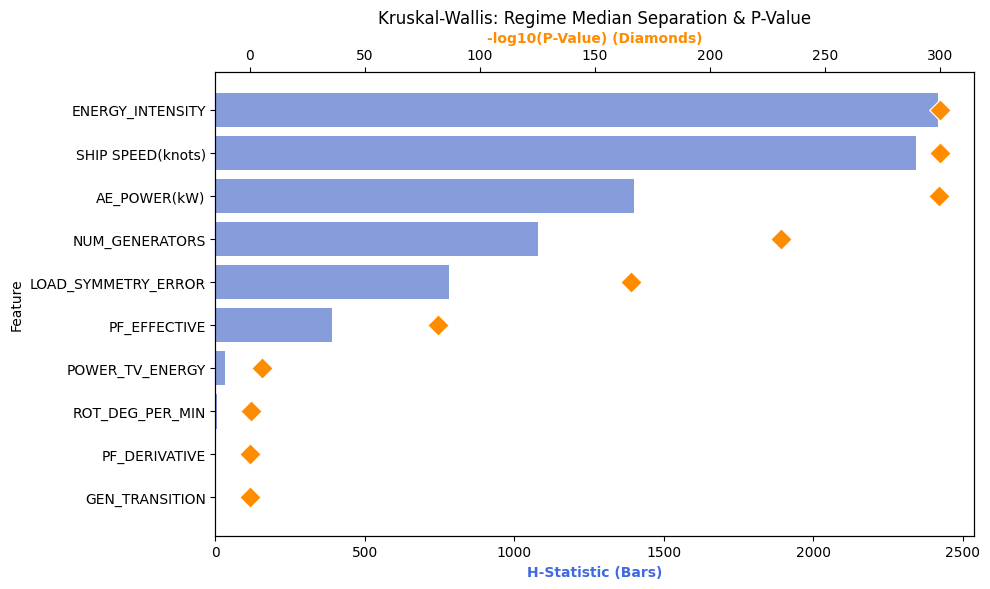

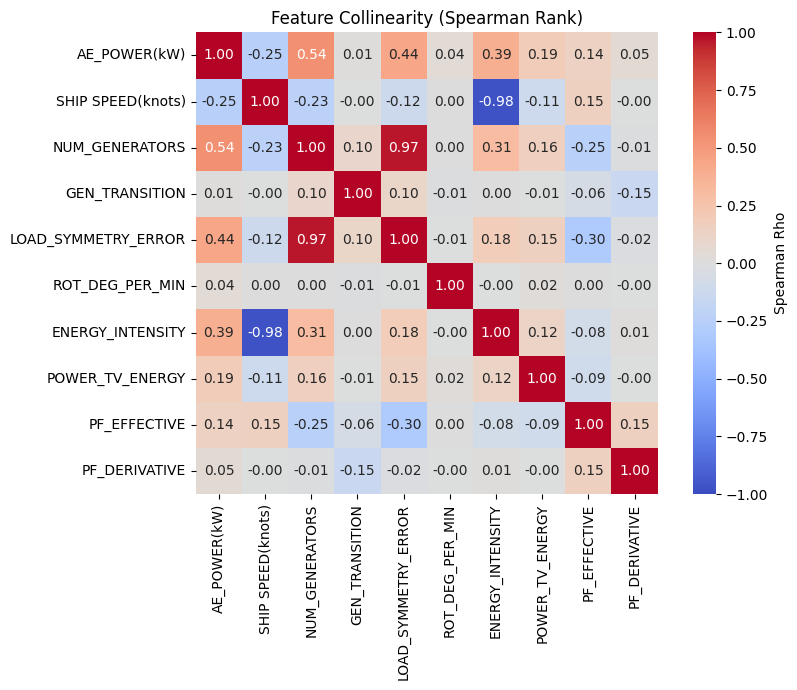

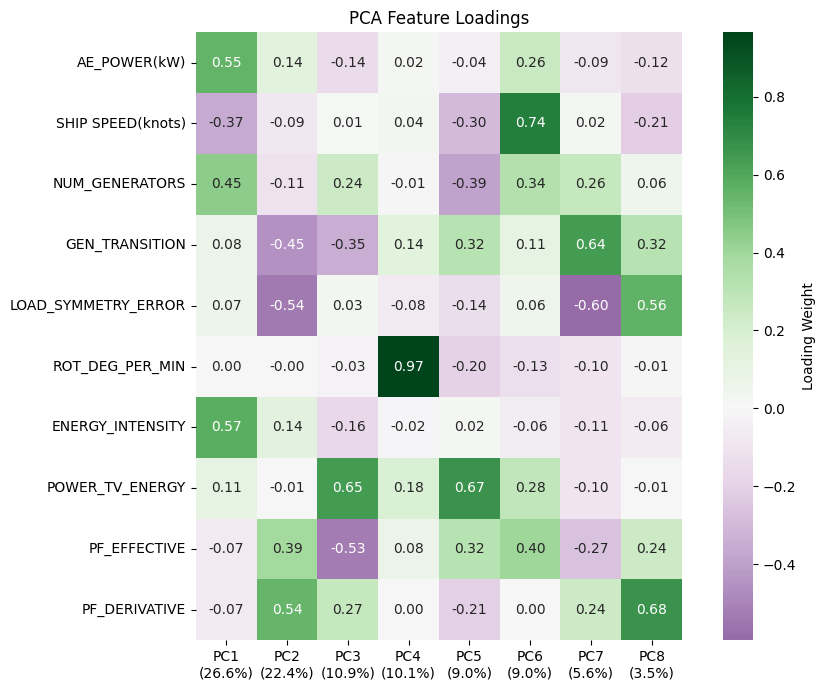

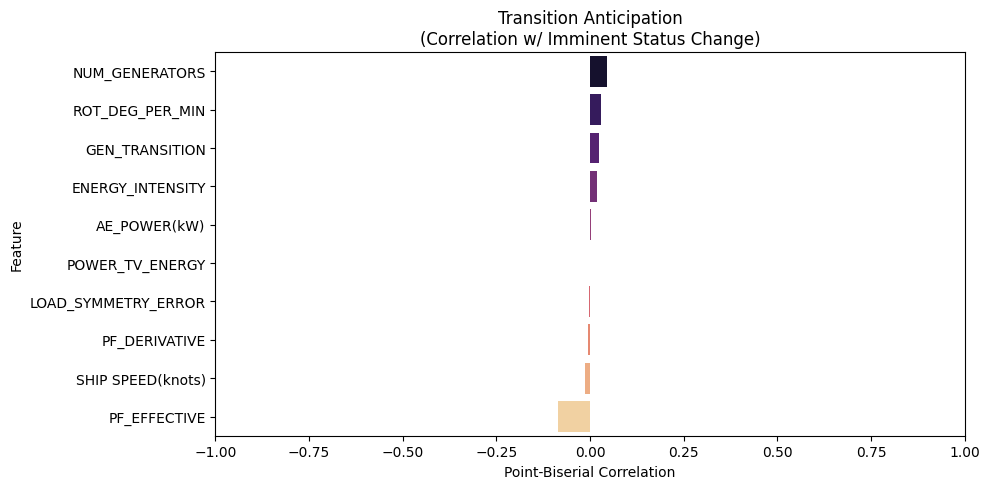

# MARINER Feature Evaluation Report

## 1. Statistical Divergence (Kruskal-Wallis H-Test)
*(Higher H-Statistic indicates stronger median separation. Low P-Value indicates statistical significance.)*
| Feature             |   H-Statistic |   P-Value |
|:--------------------|--------------:|----------:|
| ENERGY_INTENSITY    |      2418.24  | 0         |
| SHIP SPEED(knots)   |      2342.14  | 0         |
| AE_POWER(kW)        |      1399.47  | 1.79e-300 |
| NUM_GENERATORS      |      1080.7   | 2.02e-231 |
| LOAD_SYMMETRY_ERROR |       779.799 | 2.71e-166 |
| PF_EFFECTIVE        |       391.658 | 1.86e-82  |
| POWER_TV_ENERGY     |        32.43  | 4.88e-06  |
| ROT_DEG_PER_MIN     |         6.603 | 0.252     |
| PF_DERIVATIVE       |         0.477 | 0.993     |
| GEN_TRANSITION      |         0.1   | 1         |


## 2. Feature Collinearity (Spearman Rank Correlation)
*(Values > 0.75 or < -0.75 indicate highly redundant physical information)*
| Feature 1           | Feature 2         | 

In [4]:
evaluator1 = FeatureEvaluator(df1, target_col='STATUS')

evaluation1=evaluator1.evaluate(all_features, strategy='all')

evaluator1.plot_diagnostics(evaluation1)

print(evaluator1.generate_markdown_report(evaluation1))